In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\abc\Desktop\data\dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [2]:
df.columns=df.columns.str.strip().str.lower()
df.head()

,transaction id,item,quantity,price per unit,total spent,payment method,location,transaction date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction id    10000 non-null  str    
 1   item              9667 non-null   str    
 2   quantity          9521 non-null   float64
 3   price per unit    9467 non-null   float64
 4   total spent       9498 non-null   float64
 5   payment method    7421 non-null   str    
 6   location          6735 non-null   str    
 7   transaction date  9841 non-null   str    
dtypes: float64(3), str(5)
memory usage: 625.1 KB


In [5]:
df['quantity']= pd.to_numeric(df['quantity'], errors='coerce')

In [8]:
df['price per unit']= pd.to_numeric(df['price per unit'], errors='coerce')
df['total spent']= pd.to_numeric(df['total spent'], errors='coerce')

In [11]:
invalid_values = ['unknown', 'error', 'nan', 'NaN', 'UNKNOWN', 'NAN', ' ']

df = df.replace(invalid_values, np.nan)

In [14]:
# Convert numeric columns
numeric_cols = ['price per unit', 'quantity', 'total spent']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ---------------------------------------------------
# Fill missing quantity
# quantity = total_spent / price_per_unit
# ---------------------------------------------------

df['quantity'] = np.where(
    df['quantity'].isna() &
    df['total spent'].notna() &
    df['price per unit'].notna(),

    df['total spent'] / df['price per unit'],

    df['quantity']
)

# ---------------------------------------------------
# Fill missing total_spent
# total_spent = quantity * price_per_unit
# ---------------------------------------------------

df['total spent'] = np.where(
    df['total spent'].isna() &
    df['quantity'].notna() &
    df['price per unit'].notna(),

    df['quantity'] * df['price per unit'],

    df['total spent']
)

print(df)
df.isna().sum()

     transaction id      item  quantity  price per unit  total spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401       NaN       3.0             NaN          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695629    Cookie       3.0             NaN          3.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      payment method  location transaction date  
0        Credit Card  Takeaway       2023-09-08  
1               Cash  In-store     

transaction id         0
item                 677
quantity              38
price per unit       533
total spent           40
payment method      2872
location            3603
transaction date     318
dtype: int64

In [15]:
df.columns=df.columns.str.replace(' ','_')

In [16]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [17]:
# item -> price
item_to_price = (
    df.dropna(subset=['item', 'price_per_unit'])
      .drop_duplicates(subset=['item'])
      .set_index('item')['price_per_unit']
      .to_dict()
)

# price -> item
price_to_item = (
    df.dropna(subset=['item', 'price_per_unit'])
      .drop_duplicates(subset=['price_per_unit'])
      .set_index('price_per_unit')['item']
      .to_dict()
)

# -----------------------------
# Fill missing prices from item
# -----------------------------

df['price_per_unit'] = df.apply(
    lambda row: item_to_price.get(row['item'], row['price_per_unit'])
    if pd.isna(row['price_per_unit']) else row['price_per_unit'],
    axis=1
)

# -----------------------------
# Fill missing items from price
# -----------------------------

df['item'] = df.apply(
    lambda row: price_to_item.get(row['price_per_unit'], row['item'])
    if pd.isna(row['item']) else row['item'],
    axis=1
)

print(df)

     transaction_id      item  quantity  price_per_unit  total_spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401       NaN       3.0             NaN          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695629    Cookie       3.0             1.0          3.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      payment_method  location transaction_date  
0        Credit Card  Takeaway       2023-09-08  
1               Cash  In-store     

In [18]:
df.isna().sum()

transaction_id         0
item                  41
quantity              38
price_per_unit        41
total_spent           40
payment_method      2872
location            3603
transaction_date     318
dtype: int64

In [19]:
import numpy as np
import pandas as pd

# Convert columns to numeric
cols = ['quantity', 'price_per_unit', 'total_spent']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ---------------------------------------------------
# 1. Fill missing price_per_unit
# price_per_unit = total_spent / quantity
# ---------------------------------------------------

df['price_per_unit'] = np.where(
    df['price_per_unit'].isna() &
    df['quantity'].notna() &
    df['total_spent'].notna(),

    df['total_spent'] / df['quantity'],

    df['price_per_unit']
)

# ---------------------------------------------------
# 2. Fill missing total_spent
# total_spent = quantity * price_per_unit
# ---------------------------------------------------

df['total_spent'] = np.where(
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna(),

    df['quantity'] * df['price_per_unit'],

    df['total_spent']
)

# ---------------------------------------------------
# 3. Fill missing quantity
# quantity = total_spent / price_per_unit
# ---------------------------------------------------

df['quantity'] = np.where(
    df['quantity'].isna() &
    df['total_spent'].notna() &
    df['price_per_unit'].notna(),

    df['total_spent'] / df['price_per_unit'],

    df['quantity']
)

print(df)

     transaction_id      item  quantity  price_per_unit  total_spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401       NaN       3.0             1.0          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695629    Cookie       3.0             1.0          3.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      payment_method  location transaction_date  
0        Credit Card  Takeaway       2023-09-08  
1               Cash  In-store     

In [20]:
# Remove rows where transaction_id exists
# but all other columns are empty/NaN

df = df.dropna(
    subset=[col for col in df.columns if col != 'transaction_id'],
    how='all'
)

In [21]:
df = df.dropna(subset=['quantity','total_spent'])


In [26]:
df.isna().sum()

transaction_id         0
item                 160
quantity               0
price_per_unit         0
total_spent            0
payment_method      2864
location            3595
transaction_date     318
dtype: int64

In [25]:
price_item_table = df.groupby('price_per_unit')['item'].unique().reset_index()

print(price_item_table)

   price_per_unit                       item
0             1.0                   [Cookie]
1             1.5                      [Tea]
2             2.0                   [Coffee]
3             3.0         [Cake, Juice, nan]
4             4.0  [Smoothie, Sandwich, nan]
5             5.0                    [Salad]


In [24]:
import pandas as pd
import numpy as np

# Prices you want to target
target_prices = [1, 1.5, 2, 5]

# Replace invalid item values with NaN
invalid_values = ['UNKNOWN', 'ERROR', 'unknown', 'error', 'nan', 'NaN', '']

df['item'] = df['item'].replace(invalid_values, np.nan)

# Ensure numeric prices
df['price_per_unit'] = pd.to_numeric(df['price_per_unit'], errors='coerce')

# ---------------------------------------------------
# Build mapping:
# price_per_unit -> corresponding item
# ---------------------------------------------------

price_to_item = (
    df[
        df['price_per_unit'].isin(target_prices) &
        df['item'].notna()
    ]
    .groupby('price_per_unit')['item']
    .agg(lambda x: x.mode().iloc[0])   # most common item
    .to_dict()
)

# ---------------------------------------------------
# Fill missing items only for target prices
# ---------------------------------------------------

mask = (
    df['price_per_unit'].isin(target_prices) &
    df['item'].isna()
)

df.loc[mask, 'item'] = (
    df.loc[mask, 'price_per_unit']
      .map(price_to_item)
)

print(df)

     transaction_id      item  quantity  price_per_unit  total_spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401    Cookie       3.0             1.0          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695629    Cookie       3.0             1.0          3.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      payment_method  location transaction_date  
0        Credit Card  Takeaway       2023-09-08  
1               Cash  In-store     

In [27]:
df.dropna()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
6,TXN_4433211,Cake,3.0,3.0,9.0,ERROR,Takeaway,2023-10-06
...,...,...,...,...,...,...,...,...
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-store,2023-07-20
9984,TXN_3142496,Smoothie,1.0,4.0,4.0,Cash,Takeaway,2023-07-27
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24


In [28]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 9976, dtype: bool

In [29]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Clean date column
# -----------------------------

df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    errors='coerce'   # invalid formats → NaT
)

# -----------------------------
# 2. Sort by transaction_id
# (important for sequence filling)
# -----------------------------

df = df.sort_values('transaction_id').reset_index(drop=True)

# -----------------------------
# 3. Fill missing dates in sequence
# (forward fill first valid date)
# -----------------------------

df['transaction_date'] = df['transaction_date'].ffill()

# -----------------------------
# 4. OPTIONAL: if you want strictly increasing dates
# (adds 1 day step where missing originally)
# -----------------------------

mask_missing = df['transaction_date'].isna()

start_date = df['transaction_date'].dropna().min()

df.loc[mask_missing, 'transaction_date'] = pd.date_range(
    start=start_date,
    periods=mask_missing.sum(),
    freq='D'
)

print(df)

     transaction_id      item  quantity  price_per_unit  total_spent  \
0       TXN_1000555       Tea       1.0             1.5          1.5   
1       TXN_1001832     Salad       2.0             5.0         10.0   
2       TXN_1002457    Cookie       5.0             1.0          5.0   
3       TXN_1003246     Juice       2.0             3.0          6.0   
4       TXN_1004184  Smoothie       1.0             4.0          4.0   
...             ...       ...       ...             ...          ...   
9971    TXN_9996968  Sandwich       1.0             4.0          4.0   
9972    TXN_9997263    Cookie       2.0             1.0          2.0   
9973    TXN_9997620    Cookie       2.0             1.0          2.0   
9974    TXN_9999113     Juice       4.0             3.0         12.0   
9975    TXN_9999124     Juice       2.0             3.0          6.0   

      payment_method  location transaction_date  
0        Credit Card  In-store       2023-10-19  
1               Cash  Takeaway     

In [30]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1000555,Tea,1.0,1.5,1.5,Credit Card,In-store,2023-10-19
1,TXN_1001832,Salad,2.0,5.0,10.0,Cash,Takeaway,2023-10-19
2,TXN_1002457,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-09-29
3,TXN_1003246,Juice,2.0,3.0,6.0,NaN,NaN,2023-02-15
4,TXN_1004184,Smoothie,1.0,4.0,4.0,Credit Card,In-store,2023-05-18


In [31]:
df = df[
    df['transaction_id'].notna() &
    (df['transaction_id'].astype(str).str.strip() != '')
]

In [32]:
df.isna().sum()

transaction_id         0
item                 160
quantity               0
price_per_unit         0
total_spent            0
payment_method      2864
location            3595
transaction_date       0
dtype: int64

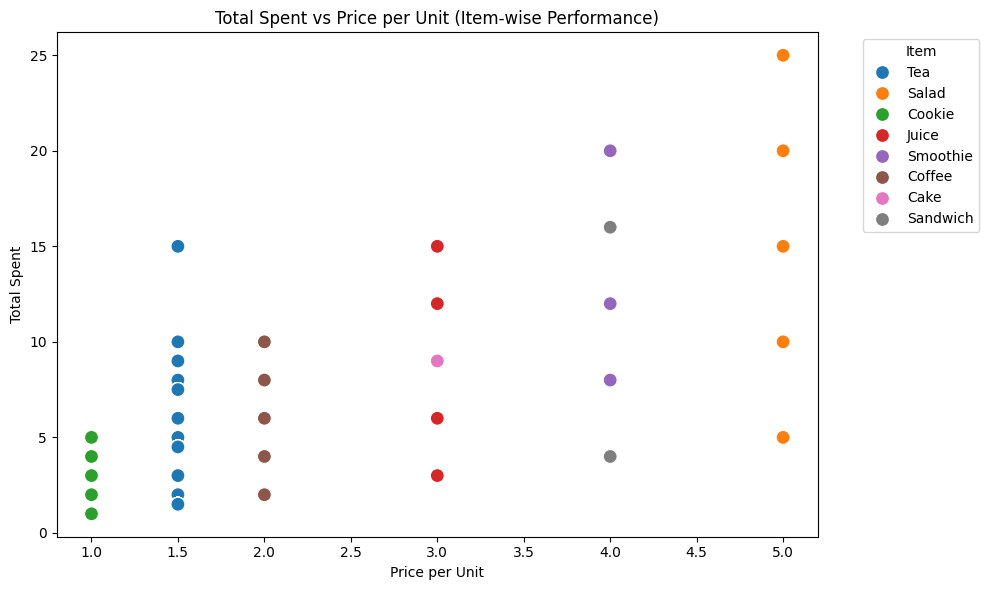

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ensure numeric
df['price_per_unit'] = pd.to_numeric(df['price_per_unit'], errors='coerce')
df['total_spent'] = pd.to_numeric(df['total_spent'], errors='coerce')

# remove missing values needed for plot
plot_df = df.dropna(subset=['price_per_unit', 'total_spent', 'item'])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='price_per_unit',
    y='total_spent',
    hue='item',
    palette='tab10',
    s=100
)

plt.title('Total Spent vs Price per Unit (Item-wise Performance)')
plt.xlabel('Price per Unit')
plt.ylabel('Total Spent')
plt.legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"C:\Users\abc\Desktop\data\graph for data clean\price&unit.png",bbox_inches='tight')
plt.show()

In [35]:
df['item'].unique()

<StringArray>
[     'Tea',    'Salad',   'Cookie',    'Juice', 'Smoothie',   'Coffee',
     'Cake', 'Sandwich',        nan]
Length: 9, dtype: str

In [45]:
# Example: items you want to analyze
target_items = ['Sandwich']

# Filter selected items
filtered_df = df[df['item'].isin(target_items)]

# Create table:
# item + location + payment_method with counts
summary_table = (
    filtered_df
    .groupby(['item', 'location', 'payment_method'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(summary_table)

        item  location  payment_method  count
6   Sandwich  In-store  Digital Wallet     88
10  Sandwich  Takeaway  Digital Wallet     86
8   Sandwich  Takeaway            Cash     83
4   Sandwich  In-store            Cash     81
5   Sandwich  In-store     Credit Card     76
9   Sandwich  Takeaway     Credit Card     71
0   Sandwich     ERROR            Cash     11
1   Sandwich     ERROR     Credit Card     10
11  Sandwich  Takeaway           ERROR      8
2   Sandwich     ERROR  Digital Wallet      8
7   Sandwich  In-store           ERROR      7
3   Sandwich     ERROR           ERROR      3


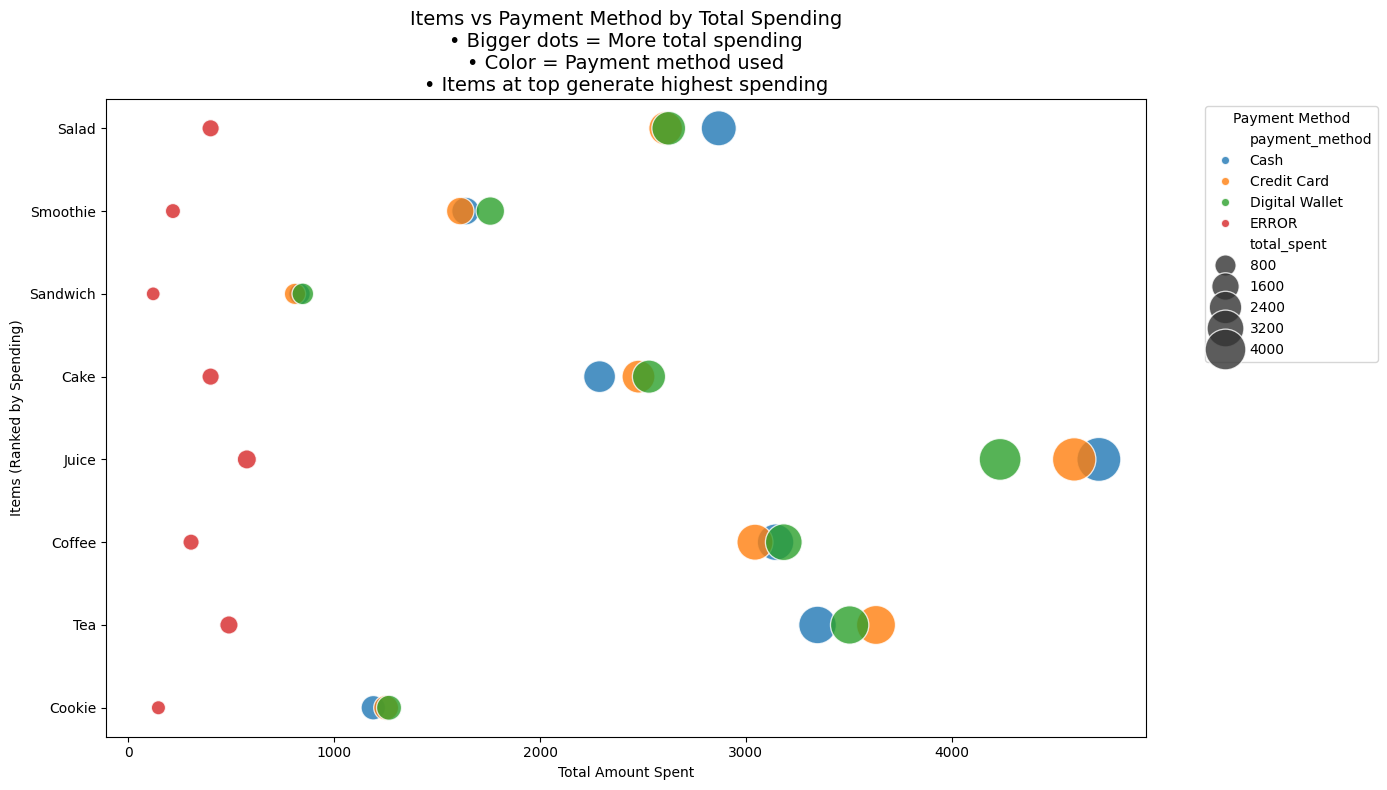

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Clean numeric column
# ---------------------------------------------------

df['total_spent'] = pd.to_numeric(df['total_spent'], errors='coerce')

# ---------------------------------------------------
# Create summary:
# item + payment_method + total_spent
# ---------------------------------------------------

summary = (
    df.groupby(['item', 'payment_method'])['total_spent']
      .sum()
      .reset_index()
)

# ---------------------------------------------------
# Sort items by highest spending
# (items with biggest total appear on top)
# ---------------------------------------------------

item_order = (
    summary.groupby('item')['total_spent']
    .sum()
    .sort_values(ascending=False)
    .index
)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=summary,
    x='total_spent',
    y='item',
    hue='payment_method',
    size='total_spent',
    sizes=(100, 1000),
    alpha=0.8
)

# Arrange items in descending order
plt.yticks(range(len(item_order)), item_order)

plt.title(
    'Items vs Payment Method by Total Spending\n'
    '• Bigger dots = More total spending\n'
    '• Color = Payment method used\n'
    '• Items at top generate highest spending',
    fontsize=14
)

plt.xlabel('Total Amount Spent')
plt.ylabel('Items (Ranked by Spending)')

plt.legend(
    title='Payment Method',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig(r"C:\Users\abc\Desktop\data\graph for data clean\payment.png",bbox_inches='tight')
plt.show()

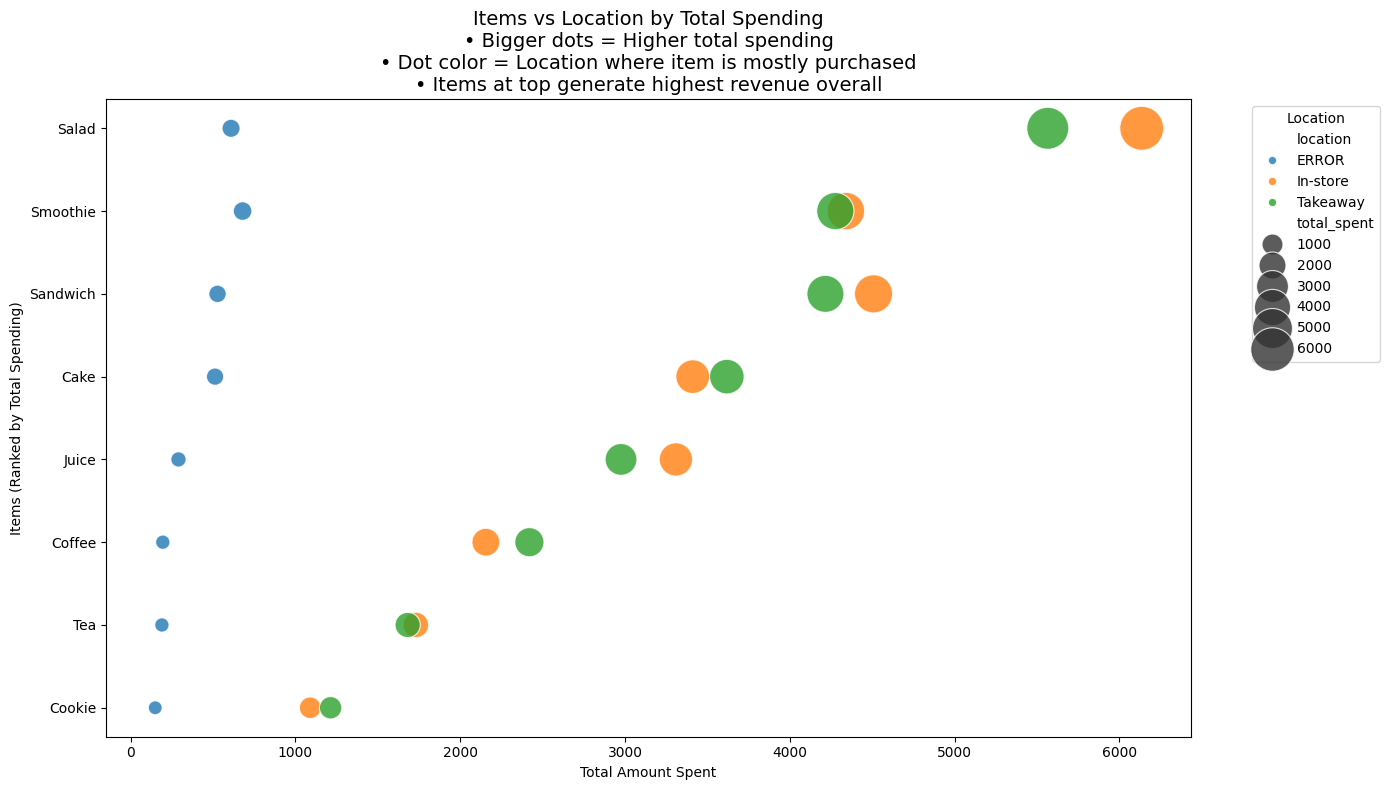

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Clean numeric column
# ---------------------------------------------------

df['total_spent'] = pd.to_numeric(df['total_spent'], errors='coerce')

# ---------------------------------------------------
# Create summary:
# item + location + total_spent
# ---------------------------------------------------

summary = (
    df.groupby(['item', 'location'])['total_spent']
      .sum()
      .reset_index()
)

# ---------------------------------------------------
# Sort items by highest spending
# ---------------------------------------------------

item_order = (
    summary.groupby('item')['total_spent']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Convert item to ordered categorical
summary['item'] = pd.Categorical(
    summary['item'],
    categories=item_order,
    ordered=True
)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=summary,
    x='total_spent',
    y='item',
    hue='location',
    size='total_spent',
    sizes=(100, 1000),
    alpha=0.8
)

plt.title(
    'Items vs Location by Total Spending\n'
    '• Bigger dots = Higher total spending\n'
    '• Dot color = Location where item is mostly purchased\n'
    '• Items at top generate highest revenue overall',
    fontsize=14
)

plt.xlabel('Total Amount Spent')
plt.ylabel('Items (Ranked by Total Spending)')

plt.legend(
    title='Location',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig(r"C:\Users\abc\Desktop\data\graph for data clean\location.png",bbox_inches='tight')
plt.show()